In [850]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from time import perf_counter
from torchinfo import summary

In [851]:
def print_dir(obj):
    for i in dir(obj):
        if i.startswith("_"):
            continue
        print(i)

In [852]:
X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)
x1 = X[y==0,0]
y1 = X[y==0,1]
x2 = X[y==1,0]
y2 = X[y==1,1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.Tensor(y_train)
y_test = torch.Tensor(y_test)
print(X.shape)
print(y.shape)
print(y_train.shape)

(1000, 2)
(1000,)
torch.Size([800])


In [853]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [854]:
class MoonsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,20)
        self.fc2 = nn.Linear(20, 20)
        self.fc3 = nn.Linear(20,40)
        self.fc4 = nn.Linear(40,1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x= self.fc2(x)
        x = self.relu(x)
        x= self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [855]:
summary(MoonsClassifier())

Layer (type:depth-idx)                   Param #
MoonsClassifier                          --
├─Linear: 1-1                            60
├─Linear: 1-2                            420
├─Linear: 1-3                            840
├─Linear: 1-4                            41
├─ReLU: 1-5                              --
Total params: 1,361
Trainable params: 1,361
Non-trainable params: 0

In [856]:
def train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, sampling_rate):
    t1 = perf_counter()
    train_losses = []
    test_losses = []
    test_accuracies = []
    train_accuracies = []
    model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device).reshape(-1,1)
    X_test = X_test.to(device)
    y_test = y_test.to(device).reshape(-1,1)
    y_pred = torch.Tensor().to(device)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        if (epoch%sampling_rate==0):
            model.eval()
            with torch.no_grad():
            #     acc = torch.Tensor(model(x_train) - y_train).abs().sum() / len(x_train)
                # acc = 1-torch.Tensor(nn.Sigmoid()(model(x_test)-y_test).abs().sum().item()/len(x_test)
                y_train_pred = model(X_train)
                y_test_pred = model(X_test)
                test_acc = ((torch.sigmoid(y_test_pred) >= 0.5) == y_test).float().mean()
                train_acc = ((torch.sigmoid(y_train_pred) >= 0.5) == y_train).float().mean()
                test_loss = criterion(y_test_pred, y_test).detach().cpu()

                print(f"epoch {epoch}:\ttrain_loss: {train_loss:.6f}\ttest_loss: {test_loss:.6f}\ttest_acc: {test_acc:.3f}\ttrain_acc: {train_acc:.3f}")     
                train_losses.append(train_loss.item())
                test_accuracies.append(test_acc.detach().cpu())
                train_accuracies.append(train_acc.detach().cpu())
                test_losses.append(test_loss)
        
    print(f"dt: {(perf_counter()-t1):.2f}s")
    _, axis = plt.subplots(2)
    axis[0].plot(train_losses, color="red")
    axis[0].plot(test_losses)
    axis[0].grid(True)
    axis[1].plot(test_accuracies)
    axis[1].grid(True)
    axis[1].plot(train_accuracies, color="red")
    axis[1].grid(True)
    plt.show()


In [857]:
model = MoonsClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 400

epoch 0:	train_loss: 0.694396	test_loss: 0.692303	test_acc: 0.500	train_acc: 0.500
epoch 20:	train_loss: 0.653887	test_loss: 0.647956	test_acc: 0.805	train_acc: 0.804
epoch 40:	train_loss: 0.582537	test_loss: 0.566432	test_acc: 0.835	train_acc: 0.809
epoch 60:	train_loss: 0.473990	test_loss: 0.439297	test_acc: 0.865	train_acc: 0.815
epoch 80:	train_loss: 0.379416	test_loss: 0.321558	test_acc: 0.890	train_acc: 0.840
epoch 100:	train_loss: 0.322083	test_loss: 0.249311	test_acc: 0.910	train_acc: 0.864
epoch 120:	train_loss: 0.294623	test_loss: 0.217177	test_acc: 0.925	train_acc: 0.866
epoch 140:	train_loss: 0.274432	test_loss: 0.198876	test_acc: 0.925	train_acc: 0.875
epoch 160:	train_loss: 0.251926	test_loss: 0.181360	test_acc: 0.930	train_acc: 0.892
epoch 180:	train_loss: 0.224361	test_loss: 0.160334	test_acc: 0.940	train_acc: 0.901
epoch 200:	train_loss: 0.192327	test_loss: 0.137320	test_acc: 0.955	train_acc: 0.920
epoch 220:	train_loss: 0.159847	test_loss: 0.112907	test_acc: 0.965	tra

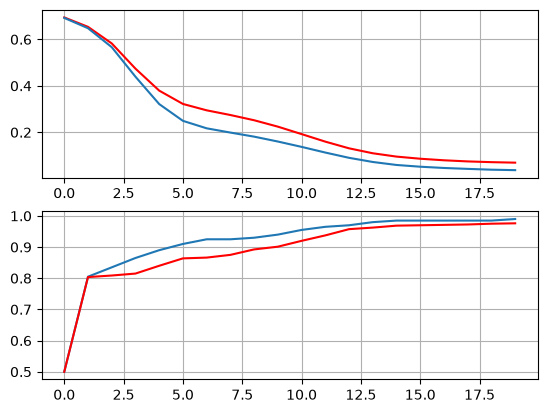

In [858]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

In [859]:
def visualize(model, title=None):
    model.eval()
    with torch.no_grad():
        xx, yy = np.meshgrid(
            np.linspace(-1.5, 2.5, 500),
            np.linspace(-1.5, 1.5, 500)
        )

        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
        y_pred = torch.sigmoid(model(grid)).detach().cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(10,5))
    plt.title(title or model.__class__.__name__)   # <-- Add this
    plt.contourf(xx, yy, y_pred, levels=20, cmap="RdBu", alpha=0.6)

    plt.scatter(x1, y1, c="blue")
    plt.scatter(x2, y2, c="red")
    plt.show()

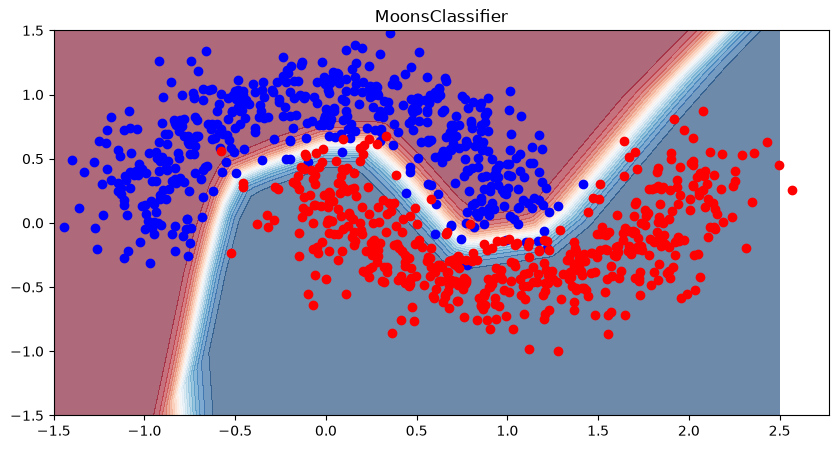

In [860]:
visualize(model)

In [861]:
model = MoonsClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=1, weight_decay=1e-4)
epochs = 1_000

epoch 0:	train_loss: 0.694007	test_loss: 0.688033	test_acc: 0.545	train_acc: 0.561
epoch 20:	train_loss: 0.327290	test_loss: 0.236528	test_acc: 0.920	train_acc: 0.860
epoch 40:	train_loss: 0.276887	test_loss: 0.191647	test_acc: 0.940	train_acc: 0.875
epoch 60:	train_loss: 0.817131	test_loss: 0.262640	test_acc: 0.885	train_acc: 0.856
epoch 80:	train_loss: 0.491584	test_loss: 0.331382	test_acc: 0.860	train_acc: 0.846
epoch 100:	train_loss: 0.185976	test_loss: 0.097146	test_acc: 0.975	train_acc: 0.938
epoch 120:	train_loss: 0.097424	test_loss: 0.058312	test_acc: 0.975	train_acc: 0.964
epoch 140:	train_loss: 0.099535	test_loss: 0.061818	test_acc: 0.980	train_acc: 0.962
epoch 160:	train_loss: 0.084658	test_loss: 0.055623	test_acc: 0.980	train_acc: 0.969
epoch 180:	train_loss: 0.081344	test_loss: 0.048170	test_acc: 0.985	train_acc: 0.972
epoch 200:	train_loss: 0.078964	test_loss: 0.044535	test_acc: 0.990	train_acc: 0.971
epoch 220:	train_loss: 0.084107	test_loss: 0.046750	test_acc: 0.990	tra

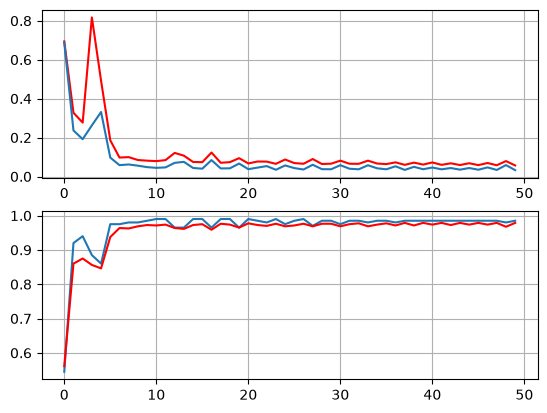

In [862]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

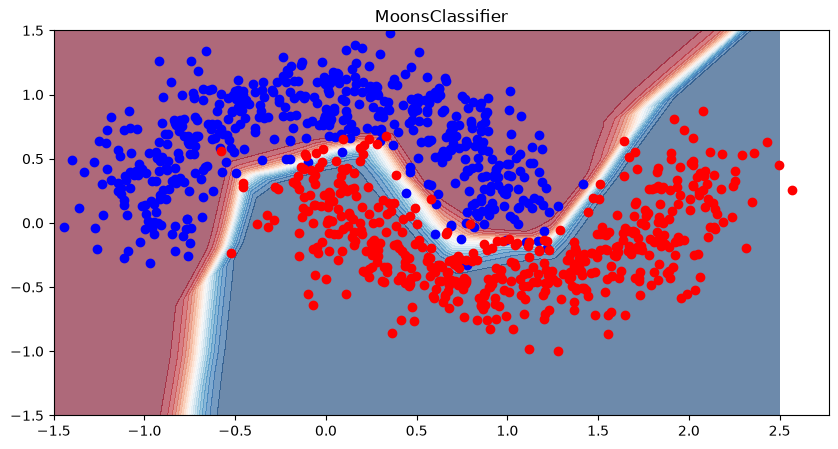

In [863]:
visualize(model)

In [864]:
model = MoonsClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-3, momentum=.9)
epochs = 1_000

epoch 0:	train_loss: 0.695404	test_loss: 0.693589	test_acc: 0.500	train_acc: 0.500
epoch 20:	train_loss: 0.450514	test_loss: 0.392609	test_acc: 0.855	train_acc: 0.797
epoch 40:	train_loss: 0.267743	test_loss: 0.178423	test_acc: 0.940	train_acc: 0.880
epoch 60:	train_loss: 0.153428	test_loss: 0.103419	test_acc: 0.965	train_acc: 0.945
epoch 80:	train_loss: 0.088994	test_loss: 0.055996	test_acc: 0.985	train_acc: 0.964
epoch 100:	train_loss: 0.075918	test_loss: 0.040120	test_acc: 0.985	train_acc: 0.972
epoch 120:	train_loss: 0.072185	test_loss: 0.036932	test_acc: 0.985	train_acc: 0.969
epoch 140:	train_loss: 0.070175	test_loss: 0.035432	test_acc: 0.990	train_acc: 0.974
epoch 160:	train_loss: 0.068966	test_loss: 0.033752	test_acc: 0.990	train_acc: 0.974
epoch 180:	train_loss: 0.068073	test_loss: 0.032984	test_acc: 0.990	train_acc: 0.975
epoch 200:	train_loss: 0.067350	test_loss: 0.032246	test_acc: 0.995	train_acc: 0.976
epoch 220:	train_loss: 0.066688	test_loss: 0.031567	test_acc: 0.995	tra

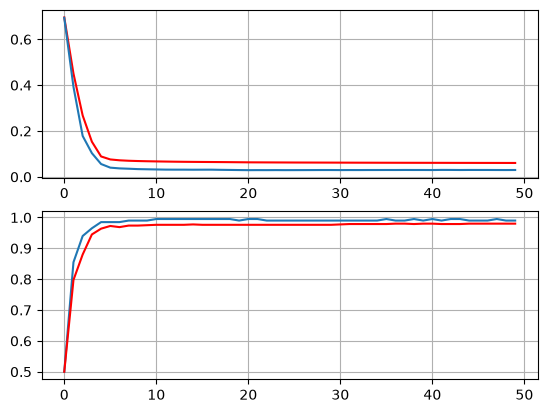

In [865]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

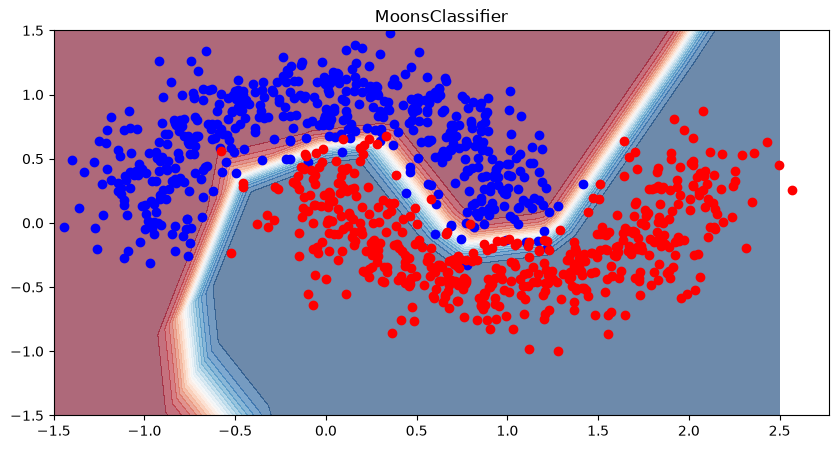

In [866]:
visualize(model)

In [867]:
model = MoonsClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 500

epoch 0:	train_loss: 0.690108	test_loss: 0.688380	test_acc: 0.775	train_acc: 0.756
epoch 20:	train_loss: 0.650748	test_loss: 0.646290	test_acc: 0.720	train_acc: 0.717
epoch 40:	train_loss: 0.578603	test_loss: 0.565400	test_acc: 0.745	train_acc: 0.750
epoch 60:	train_loss: 0.469825	test_loss: 0.438066	test_acc: 0.835	train_acc: 0.777
epoch 80:	train_loss: 0.367778	test_loss: 0.313554	test_acc: 0.870	train_acc: 0.819
epoch 100:	train_loss: 0.294785	test_loss: 0.229530	test_acc: 0.915	train_acc: 0.870
epoch 120:	train_loss: 0.244721	test_loss: 0.179491	test_acc: 0.940	train_acc: 0.904
epoch 140:	train_loss: 0.208462	test_loss: 0.147387	test_acc: 0.960	train_acc: 0.917
epoch 160:	train_loss: 0.176014	test_loss: 0.123605	test_acc: 0.960	train_acc: 0.939
epoch 180:	train_loss: 0.146997	test_loss: 0.102542	test_acc: 0.965	train_acc: 0.949
epoch 200:	train_loss: 0.123317	test_loss: 0.084848	test_acc: 0.975	train_acc: 0.959
epoch 220:	train_loss: 0.105829	test_loss: 0.071236	test_acc: 0.980	tra

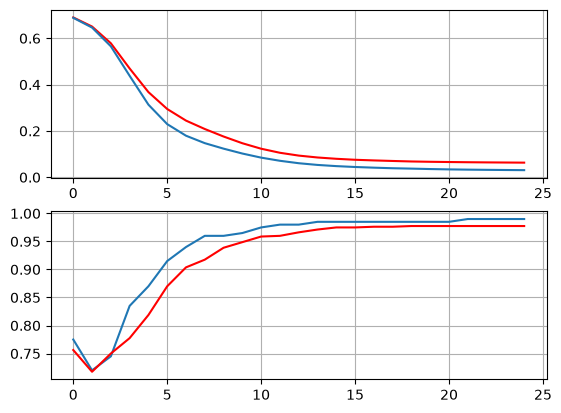

In [868]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

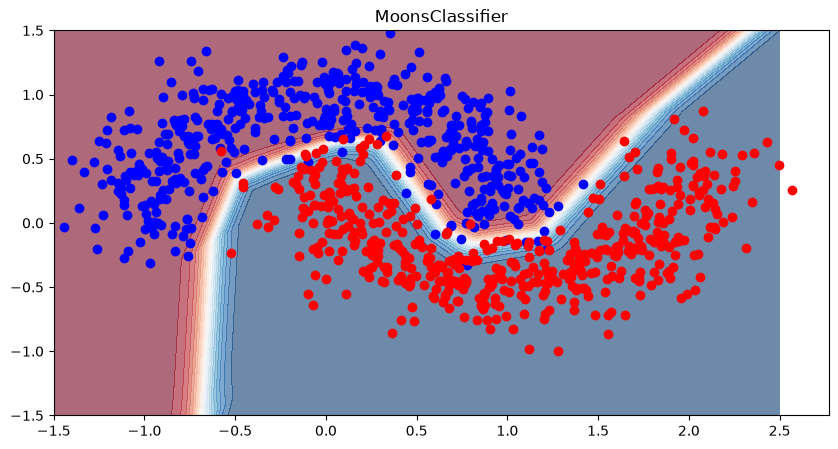

In [869]:
visualize(model)

In [870]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=80,
    test_size=920,
    random_state=42,
    stratify=y
)
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.Tensor(y_train)
y_test = torch.Tensor(y_test)

In [871]:
class OverfittingMoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [872]:
summary(OverfittingMoonClassifier())

Layer (type:depth-idx)                   Param #
OverfittingMoonClassifier                --
├─Linear: 1-1                            384
├─Linear: 1-2                            16,512
├─Linear: 1-3                            129
├─ReLU: 1-4                              --
Total params: 17,025
Trainable params: 17,025
Non-trainable params: 0

In [873]:
class DropoutMoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

In [874]:
summary(DropoutMoonClassifier())

Layer (type:depth-idx)                   Param #
DropoutMoonClassifier                    --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       384
│    └─ReLU: 2-2                         --
│    └─Dropout: 2-3                      --
│    └─Linear: 2-4                       16,512
│    └─ReLU: 2-5                         --
│    └─Dropout: 2-6                      --
│    └─Linear: 2-7                       129
Total params: 17,025
Trainable params: 17,025
Non-trainable params: 0

In [875]:
class BatchNormMoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

In [876]:
summary(BatchNormMoonClassifier())

Layer (type:depth-idx)                   Param #
BatchNormMoonClassifier                  --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       384
│    └─BatchNorm1d: 2-2                  256
│    └─ReLU: 2-3                         --
│    └─Linear: 2-4                       16,512
│    └─BatchNorm1d: 2-5                  256
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       129
Total params: 17,537
Trainable params: 17,537
Non-trainable params: 0

In [877]:
model = OverfittingMoonClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 500

epoch 0:	train_loss: 0.676202	test_loss: 0.659193	test_acc: 0.695	train_acc: 0.738
epoch 20:	train_loss: 0.351794	test_loss: 0.380681	test_acc: 0.820	train_acc: 0.875
epoch 40:	train_loss: 0.248860	test_loss: 0.282834	test_acc: 0.864	train_acc: 0.887
epoch 60:	train_loss: 0.212973	test_loss: 0.234941	test_acc: 0.897	train_acc: 0.913
epoch 80:	train_loss: 0.180093	test_loss: 0.198726	test_acc: 0.912	train_acc: 0.925
epoch 100:	train_loss: 0.146059	test_loss: 0.162055	test_acc: 0.938	train_acc: 0.938
epoch 120:	train_loss: 0.112736	test_loss: 0.130374	test_acc: 0.960	train_acc: 0.938
epoch 140:	train_loss: 0.082735	test_loss: 0.106918	test_acc: 0.968	train_acc: 0.975
epoch 160:	train_loss: 0.060956	test_loss: 0.093119	test_acc: 0.974	train_acc: 0.988
epoch 180:	train_loss: 0.045411	test_loss: 0.086745	test_acc: 0.974	train_acc: 0.988
epoch 200:	train_loss: 0.034226	test_loss: 0.084276	test_acc: 0.971	train_acc: 0.988
epoch 220:	train_loss: 0.026441	test_loss: 0.083665	test_acc: 0.971	tra

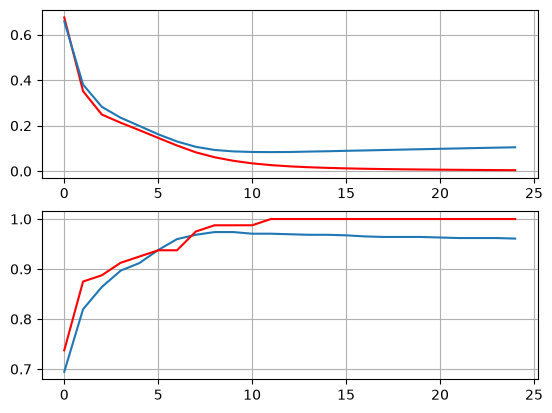

In [878]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

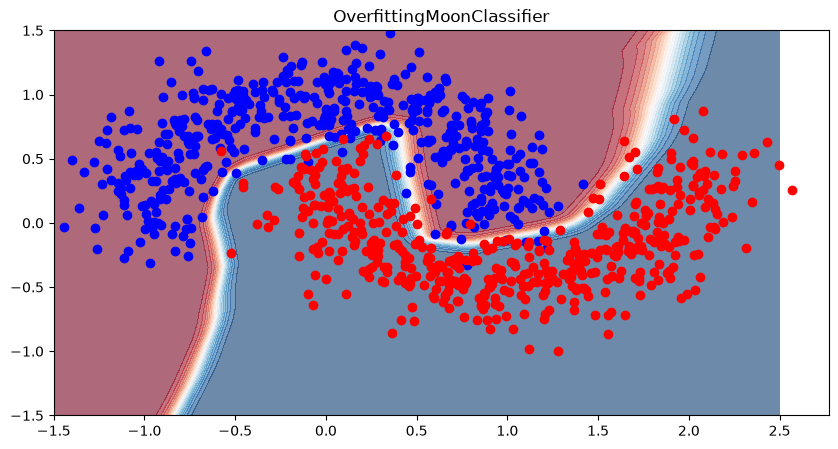

In [879]:
visualize(model)

In [880]:
model = OverfittingMoonClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
epochs = 500

epoch 0:	train_loss: 0.704729	test_loss: 0.675777	test_acc: 0.723	train_acc: 0.788
epoch 20:	train_loss: 0.350165	test_loss: 0.377236	test_acc: 0.834	train_acc: 0.875
epoch 40:	train_loss: 0.251878	test_loss: 0.286523	test_acc: 0.867	train_acc: 0.887
epoch 60:	train_loss: 0.221038	test_loss: 0.245317	test_acc: 0.890	train_acc: 0.887
epoch 80:	train_loss: 0.193281	test_loss: 0.214533	test_acc: 0.909	train_acc: 0.913
epoch 100:	train_loss: 0.163900	test_loss: 0.182428	test_acc: 0.932	train_acc: 0.938
epoch 120:	train_loss: 0.133331	test_loss: 0.151516	test_acc: 0.953	train_acc: 0.938
epoch 140:	train_loss: 0.104402	test_loss: 0.125757	test_acc: 0.967	train_acc: 0.950
epoch 160:	train_loss: 0.079503	test_loss: 0.106890	test_acc: 0.974	train_acc: 0.975
epoch 180:	train_loss: 0.060472	test_loss: 0.095050	test_acc: 0.978	train_acc: 0.988
epoch 200:	train_loss: 0.046297	test_loss: 0.088495	test_acc: 0.975	train_acc: 0.988
epoch 220:	train_loss: 0.035972	test_loss: 0.085920	test_acc: 0.973	tra

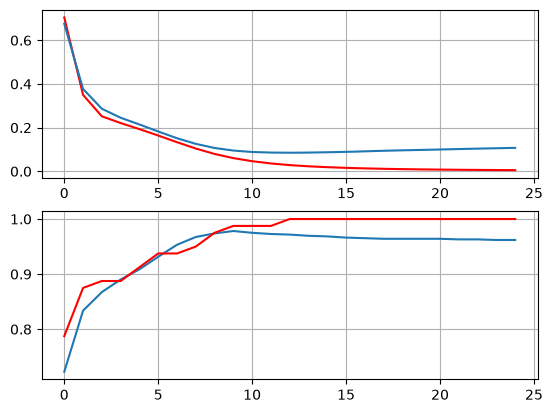

In [881]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

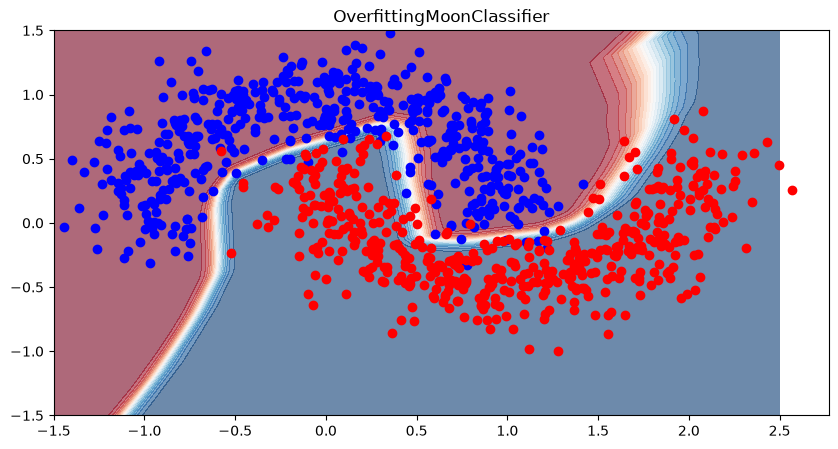

In [882]:
visualize(model)

In [883]:
model = DropoutMoonClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 500

epoch 0:	train_loss: 0.679221	test_loss: 0.656931	test_acc: 0.687	train_acc: 0.788
epoch 20:	train_loss: 0.339243	test_loss: 0.367152	test_acc: 0.825	train_acc: 0.875
epoch 40:	train_loss: 0.258648	test_loss: 0.305611	test_acc: 0.855	train_acc: 0.875
epoch 60:	train_loss: 0.241184	test_loss: 0.262832	test_acc: 0.877	train_acc: 0.900
epoch 80:	train_loss: 0.228968	test_loss: 0.234440	test_acc: 0.893	train_acc: 0.900
epoch 100:	train_loss: 0.205325	test_loss: 0.208400	test_acc: 0.908	train_acc: 0.925
epoch 120:	train_loss: 0.178250	test_loss: 0.181156	test_acc: 0.928	train_acc: 0.938
epoch 140:	train_loss: 0.171573	test_loss: 0.158353	test_acc: 0.948	train_acc: 0.938
epoch 160:	train_loss: 0.159989	test_loss: 0.139302	test_acc: 0.958	train_acc: 0.950
epoch 180:	train_loss: 0.121065	test_loss: 0.123058	test_acc: 0.971	train_acc: 0.950
epoch 200:	train_loss: 0.084053	test_loss: 0.111892	test_acc: 0.973	train_acc: 0.963
epoch 220:	train_loss: 0.099109	test_loss: 0.104361	test_acc: 0.974	tra

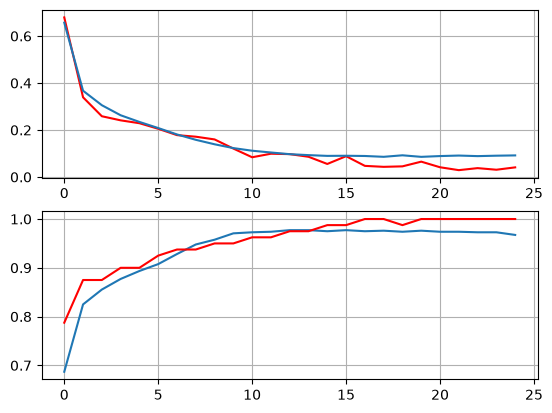

In [884]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

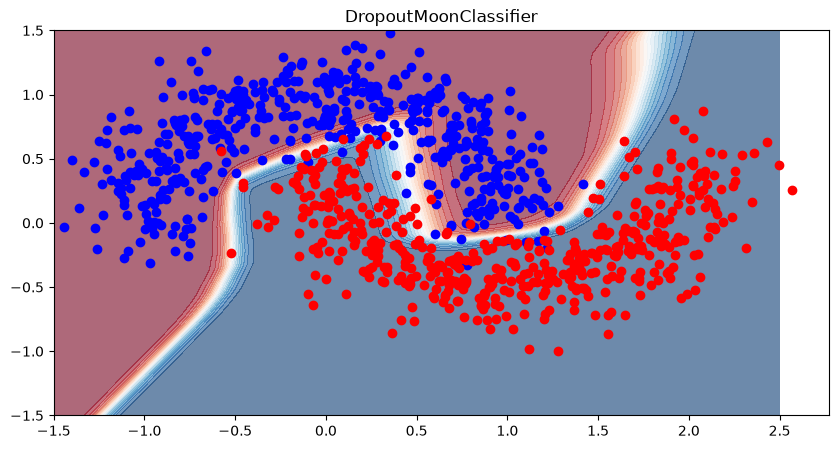

In [885]:
visualize(model)

In [886]:
model = BatchNormMoonClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 500

epoch 0:	train_loss: 0.675577	test_loss: 0.698952	test_acc: 0.468	train_acc: 0.463
epoch 20:	train_loss: 0.181699	test_loss: 0.284498	test_acc: 0.923	train_acc: 0.925
epoch 40:	train_loss: 0.139156	test_loss: 0.176961	test_acc: 0.949	train_acc: 0.950
epoch 60:	train_loss: 0.112799	test_loss: 0.147020	test_acc: 0.962	train_acc: 0.950
epoch 80:	train_loss: 0.093328	test_loss: 0.134198	test_acc: 0.965	train_acc: 0.950
epoch 100:	train_loss: 0.073700	test_loss: 0.122916	test_acc: 0.970	train_acc: 0.975
epoch 120:	train_loss: 0.048522	test_loss: 0.112248	test_acc: 0.972	train_acc: 0.988
epoch 140:	train_loss: 0.028488	test_loss: 0.100742	test_acc: 0.970	train_acc: 1.000
epoch 160:	train_loss: 0.019030	test_loss: 0.097534	test_acc: 0.967	train_acc: 1.000
epoch 180:	train_loss: 0.013499	test_loss: 0.101226	test_acc: 0.962	train_acc: 1.000
epoch 200:	train_loss: 0.010165	test_loss: 0.106576	test_acc: 0.955	train_acc: 1.000
epoch 220:	train_loss: 0.007897	test_loss: 0.110807	test_acc: 0.955	tra

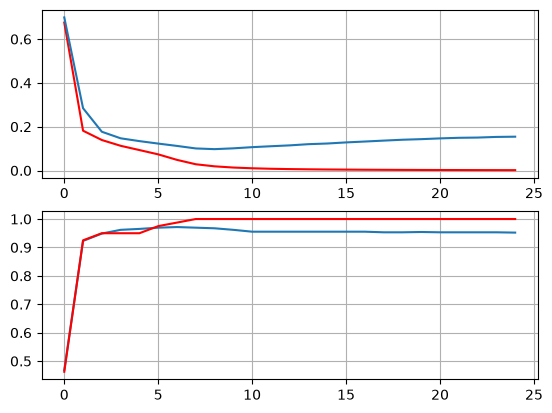

In [887]:
train(model, criterion, X_train, y_train, X_test, y_test, epochs, device, optimizer, 20)

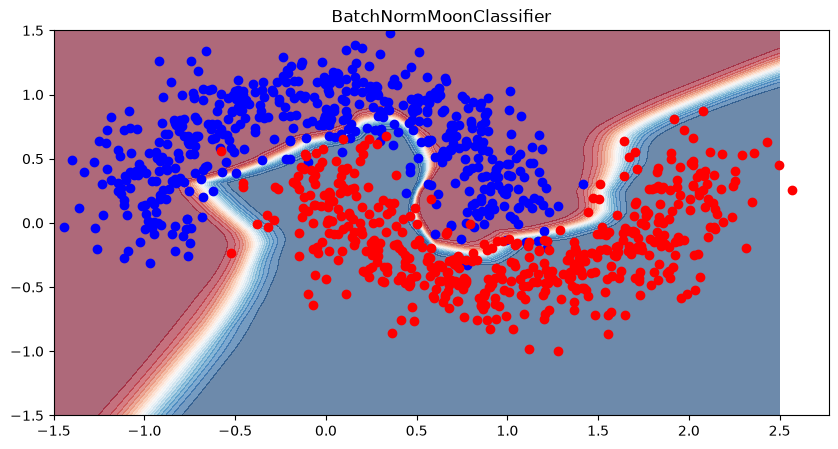

In [888]:
visualize(model)